In [1]:
import sys
import shutil

assert sys.version_info >= (3, 10)
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    !git clone https://github.com/stachuapa123/ASR_project.git

    
    %cd ASR_project

  
    !git checkout main

    !pip install torchmetrics

In [2]:
if not IS_COLAB:  # na colabie to odwala
    %load_ext autoreload
    %autoreload 2

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from scipy.io import wavfile
from src.constants import Constants as C
from pathlib import Path
import torchmetrics

In [3]:
from src.augment import augment_audio, SpecAugment
from src.parsers import build_augmented_cache_soft, build_augmented_cache
from src.parsers import PhonemeWindowDataset
from src.parsers import DoubledSoftLabelCacheDataset, SoftLabelCacheDataset
from src.NeuralModel import CRNN
from src.trainers import train_model, evaluate_tm, save_checkpoint

In [4]:
from src.trainers import SoftCrossEntropyLoss, SoftAccuracy

In [5]:
if IS_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

Duze_dane = False

In [6]:
if Duze_dane:
    !mkdir -p /content/dane_audio_lokalnie

    # tutaj to gdy robimy duże dane
    !unzip -q "/content/drive/MyDrive/asr_data/501-1000.zip" -d "/content/dane_audio_lokalnie"

In [7]:
if Duze_dane:
    # tutaj to gdy robimy duże dane
    DATA_DIR2 = "/content/dane_audio_lokalnie"
else:
    DATA_DIR2 = "../AutorskieDane/AutorskiDataset"

In [8]:
data_in_ram = None
# Wymuszamy budowanie w RAM
if True:
    print("Budowanie cache w RAM (jednorazowe, to potrwa)...")
    data_in_ram = build_augmented_cache_soft(
        data_dir=DATA_DIR2,
        output_path=None,  # Nie zapisujemy na dysku
        n_augmentations=2,  # tutaj trzeba przynajmniej 2, bo inaczej train set sie wywala, nie mialem czasu zeby to ogarnac
        standardize=True,
        silences_same=True,
        noiseprob=0.0,
        gainprob=0.0,
        tempo_prob=0.0,
        noise_level=(10, 30),
        gain_range=(-5, 5),
        tempo_range=(0.95, 1.05),
    )
    print("Cache wygenerowany w RAM!")

Budowanie cache w RAM (jednorazowe, to potrwa)...
znaleziono 31 plików


/home/stachuapa123/Desktop/ASR/ASR_project/src/parsers.py:430: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, audio_orig = wavfile.read(wav_path)


final: X=torch.Size([45027, 2, 128, 8]), y=torch.Size([45027, 39])
rozmiar: 0.38 GB
output_path=None — nie zapisuję na dysk, tylko zwracam
Cache wygenerowany w RAM!


In [9]:
if data_in_ram is not None:
    data = data_in_ram
device = "cuda" if torch.cuda.is_available() else "cpu"

X = data["X"] 
y = data["y"]
n_aug = data["n_aug"]
print(f"Załadowano: X={X.shape}, y={y.shape}, n_aug={n_aug}")

Załadowano: X=torch.Size([45027, 2, 128, 8]), y=torch.Size([45027, 39]), n_aug=2


In [10]:
generator = torch.Generator().manual_seed(0)
indices = torch.randperm(len(X), generator=generator)
n_val = int(1 * len(X))
train_idx, val_idx = indices[n_val:], indices[:n_val]
train_set = DoubledSoftLabelCacheDataset(
    X[train_idx], y[train_idx], train=True, device=device
)
val_set = SoftLabelCacheDataset(X[val_idx], y[val_idx], train=False, device=device)

In [11]:

val_loader = DataLoader(
    val_set, batch_size=1024, shuffle=False, num_workers=0, pin_memory=False
)

In [12]:
from src.trainers import load_checkpoint
CHECKPOINT_PATH = "../trained_models/BetterDataSoft.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CRNN()
meta = load_checkpoint(CHECKPOINT_PATH, model, device=device)
model.eval()

CRNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.2, inplace=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
  )
  (rnn): LSTM(204

In [13]:
def build_confusion_matrix(model, loader, device, n_classes=C.N_CLASSES):
    """Standard CM: argmax targetu vs argmax predykcji."""
    model.eval()
    cm = torch.zeros(n_classes, n_classes, dtype=torch.long)
    
    with torch.no_grad():
        for X, y_soft in loader:
            X = X.to(device)
            y_soft = y_soft.to(device)
            
            pred = model(X).argmax(dim=1)
            target = y_soft.argmax(dim=1)
            
            # zlicz pary (target, pred) — bincount trick
            indices = target * n_classes + pred
            cm_flat = torch.bincount(indices, minlength=n_classes * n_classes)
            cm += cm_flat.reshape(n_classes, n_classes).cpu()
    
    return cm.numpy()

In [14]:
def build_confusion_matrix_certainty(model, loader, device, n_classes=C.N_CLASSES,
                                       certainty_threshold=0.8):
    """Dwie CM: dla pewnych targetów (>threshold) i niepewnych (<threshold)."""
    model.eval()
    cm_certain = torch.zeros(n_classes, n_classes, dtype=torch.long)
    cm_uncertain = torch.zeros(n_classes, n_classes, dtype=torch.long)
    n_certain = 0
    n_uncertain = 0
    
    with torch.no_grad():
        for X, y_soft in loader:
            X = X.to(device)
            y_soft = y_soft.to(device)
            
            pred = model(X).argmax(dim=1)
            target = y_soft.argmax(dim=1)
            dominant_prob = y_soft.max(dim=1).values
            
            certain_mask = dominant_prob >= certainty_threshold
            uncertain_mask = ~certain_mask
            
            # CM dla pewnych
            if certain_mask.any():
                t_c = target[certain_mask]
                p_c = pred[certain_mask]
                indices = t_c * n_classes + p_c
                cm_flat = torch.bincount(indices, minlength=n_classes * n_classes)
                cm_certain += cm_flat.reshape(n_classes, n_classes).cpu()
                n_certain += certain_mask.sum().item()
            
            # CM dla niepewnych
            if uncertain_mask.any():
                t_u = target[uncertain_mask]
                p_u = pred[uncertain_mask]
                indices = t_u * n_classes + p_u
                cm_flat = torch.bincount(indices, minlength=n_classes * n_classes)
                cm_uncertain += cm_flat.reshape(n_classes, n_classes).cpu()
                n_uncertain += uncertain_mask.sum().item()
    
    print(f'pewne (>{certainty_threshold*100:.0f}%): {n_certain}')
    print(f'niepewne: {n_uncertain}')
    
    return cm_certain.numpy(), cm_uncertain.numpy()

In [15]:
def build_soft_confusion_matrix(model, loader, device, n_classes=C.N_CLASSES):
    """Soft CM: target jako rozkład, predykcja jako argmax.
    cm[i, j] = suma proporcji fonemu i gdy model przewidział j.
    """
    model.eval()
    cm = torch.zeros(n_classes, n_classes, device=device)
    
    with torch.no_grad():
        for X, y_soft in loader:
            X = X.to(device)
            y_soft = y_soft.to(device)
            
            pred = model(X).argmax(dim=1)
            
            # one-hot z predykcji
            pred_onehot = torch.zeros(len(pred), n_classes, device=device)
            pred_onehot.scatter_(1, pred.unsqueeze(1), 1.0)
            
            # cm += y_soft.T @ pred_onehot
            cm += y_soft.t() @ pred_onehot
    
    return cm.cpu().numpy()

In [16]:
cm1 = build_confusion_matrix(model, val_loader, device)

In [17]:
cm1

array([[ 539,   61,    3, ...,    1,    5,    0],
       [  40,  256,    4, ...,    0,    4,    0],
       [   4,    5, 1646, ...,   34,    1,    0],
       ...,
       [   2,    5,    4, ...,  388,    0,    0],
       [   0,    3,    0, ...,    0,   16,    0],
       [   0,    0,    0, ...,    0,    0,    0]], shape=(39, 39))

In [18]:
import matplotlib.pyplot as plt
def plot_cm(cm, labels, title='Confusion Matrix', normalize=True, figsize=(14, 12),
            cmap='Blues'):
    """Heatmap CM w czystym matplotlib."""
    if normalize:
        cm_display = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
        fmt = '.2f'
    else:
        cm_display = cm
        fmt = 'd'
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_display, cmap=cmap, aspect='auto')
    
    # colorbar
    plt.colorbar(im, ax=ax)
    
    # ticks
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    
    # annotacje (liczby w komórkach)
    threshold = cm_display.max() / 2.0
    for i in range(len(labels)):
        for j in range(len(labels)):
            value = cm_display[i, j]
            # próg: jasny tekst na ciemnym tle, ciemny na jasnym
            color = 'white' if value > threshold else 'black'
            # pomijaj prawie-zerowe wartości żeby nie zaśmiecać
            if value > 0.005 or not normalize:
                ax.text(j, i, format(value, fmt), ha='center', va='center',
                        color=color, fontsize=7)
    
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

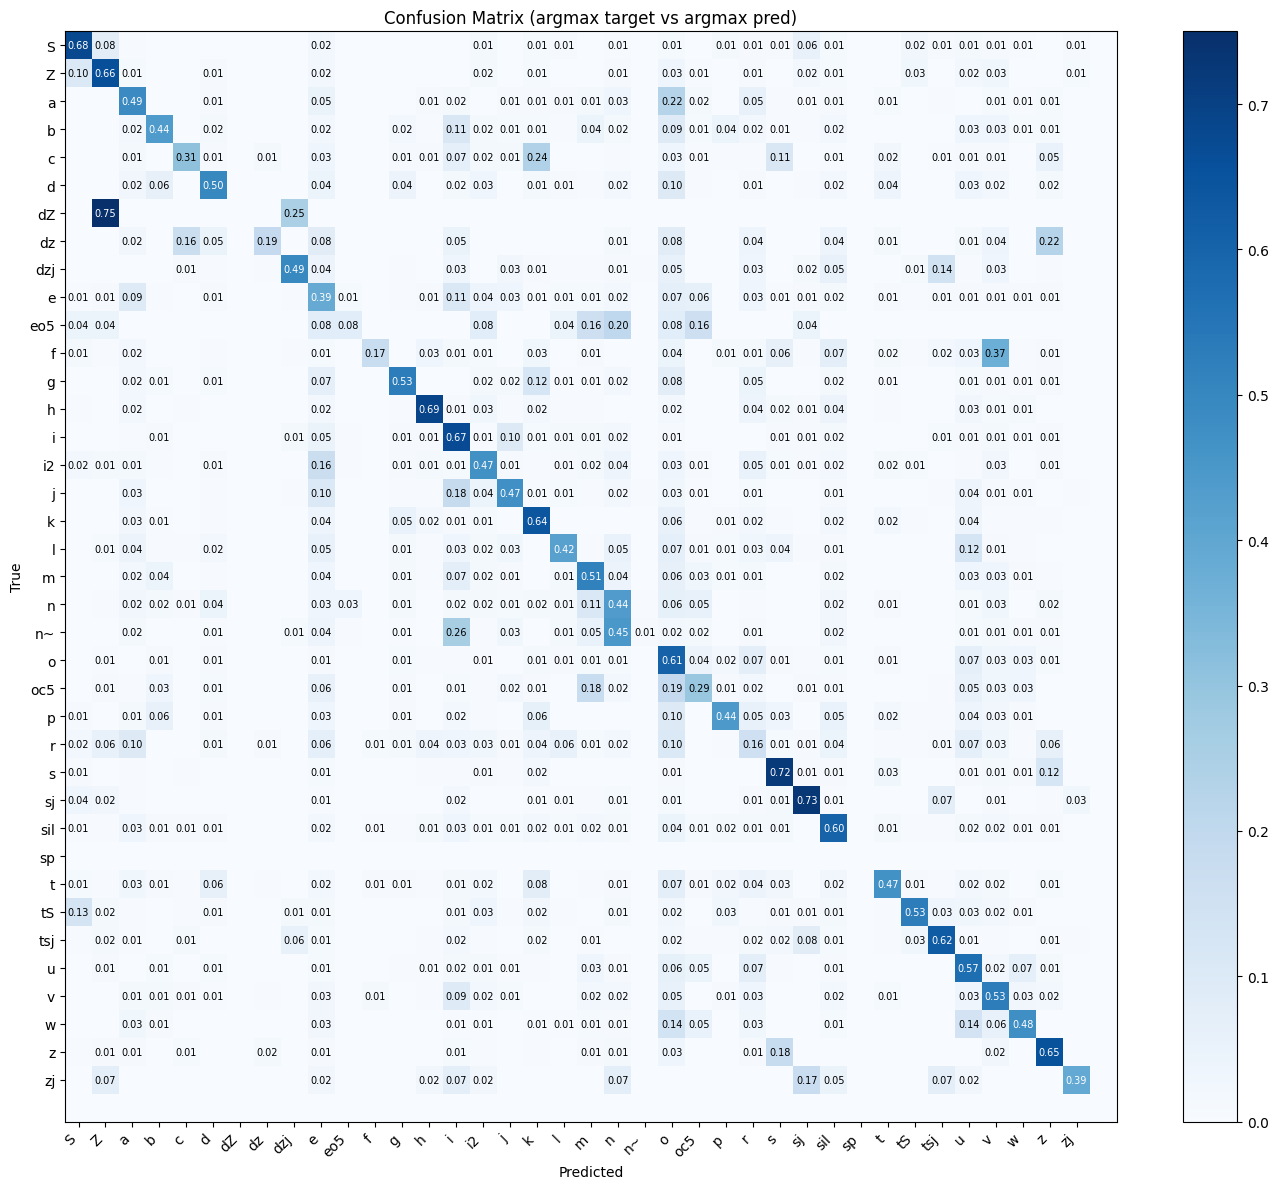

In [19]:
plot_cm(cm1, labels=C.PHONEMES, title='Confusion Matrix (argmax target vs argmax pred)')

In [20]:
cm1

array([[ 539,   61,    3, ...,    1,    5,    0],
       [  40,  256,    4, ...,    0,    4,    0],
       [   4,    5, 1646, ...,   34,    1,    0],
       ...,
       [   2,    5,    4, ...,  388,    0,    0],
       [   0,    3,    0, ...,    0,   16,    0],
       [   0,    0,    0, ...,    0,    0,    0]], shape=(39, 39))